# Machine Learning - assignment #1
### Liver Cancer Prediction
________________________________________________________________________________

## 1. Data Exploration

### Load liver_cancer_prediction.csv Dataset

In [175]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"liver_cancer_prediction.csv", sep=',')
df.sample(5)

,Country,Region,Population,Incidence_Rate,Mortality_Rate,Gender,Age,Alcohol_Consumption,Smoking_Status,Hepatitis_B_Status,...,Herbal_Medicine_Use,Healthcare_Access,Screening_Availability,Treatment_Availability,Liver_Transplant_Access,Ethnicity,Preventive_Care,Survival_Rate,Cost_of_Treatment,Prediction
125325,China,Eastern Asia,742469010,26.211406,25.167320,Male,61,Low,Non-Smoker,Negative,...,No,Good,Not Available,Available,No,Caucasian,Good,28.497291,8784.660967,Yes
18210,Ethiopia,Sub-Saharan Africa,735066953,4.214275,12.012095,Female,85,High,Non-Smoker,Negative,...,No,Good,Not Available,Not Available,No,Mixed,Moderate,67.969420,43504.316362,Yes
112002,Thailand,Southeast Asia,1417817696,6.576642,3.947314,Male,43,Low,Non-Smoker,Negative,...,No,Good,Available,Available,No,Asian,Moderate,79.961632,27887.735089,No
30020,Tanzania,Sub-Saharan Africa,116784575,10.448861,5.524439,Male,44,Low,Smoker,Negative,...,No,Poor,Not Available,Not Available,No,Mixed,Good,76.194082,732.419779,No
5295,Germany,Europe,98825447,18.664945,19.892417,Male,70,Low,Smoker,Positive,...,No,Moderate,Not Available,Not Available,No,Asian,Moderate,32.674992,36316.547103,No


In [176]:
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Values Count': df.count(),
    'Unique Values': df.nunique(),
    'Null Percentage': (df.isnull().sum() / len(df)) * 100
})

numeric_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('int|float')]
categorical_attributes_summary = summary_df[summary_df['Data Type'].astype(str).str.contains('object|category|bool')]

### Listing Numeric Attributes

In [177]:
numeric_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
Population,int64,160292,160288,0.0
Incidence_Rate,float64,160292,160292,0.0
Mortality_Rate,float64,160292,160292,0.0
Age,int64,160292,70,0.0
Survival_Rate,float64,160292,160292,0.0
Cost_of_Treatment,float64,160292,160292,0.0


### Listing Categorical Attributes

In [178]:
categorical_attributes_summary

,Data Type,Values Count,Unique Values,Null Percentage
Country,object,160292,30,0.0
Region,object,160292,10,0.0
Gender,object,160292,2,0.0
Alcohol_Consumption,object,160292,3,0.0
Smoking_Status,object,160292,2,0.0
Hepatitis_B_Status,object,160292,2,0.0
Hepatitis_C_Status,object,160292,2,0.0
Obesity,object,160292,4,0.0
Diabetes,object,160292,2,0.0
Rural_or_Urban,object,160292,2,0.0


* Data doesn't contain missing values.


⚠️ **WARNING**
A significant anomaly was noticed in the attributes listings mentioned above. While the dataset contains only `30` unique `Country` values, features that should theoretically be static per country—such as Population, Incidence_Rate, Survival_Rate, Mortality_Rate—contain over 160,000 unique values!

So Lets check `Population` and other numeric attributes distribution and then check `Population` Distribution per `Country`:

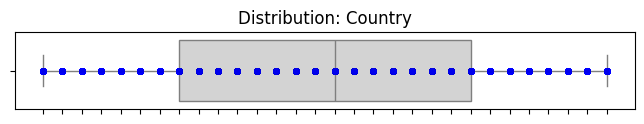

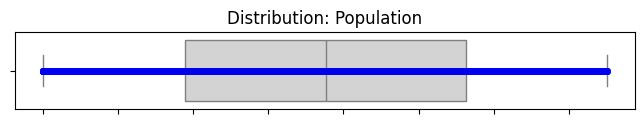

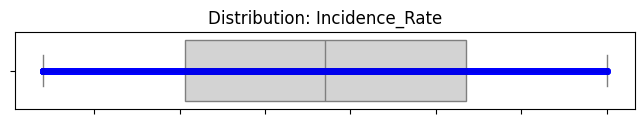

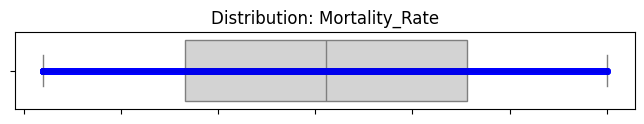

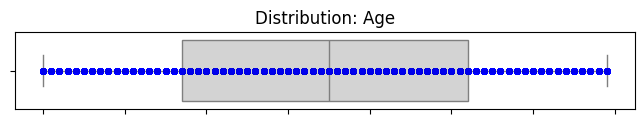

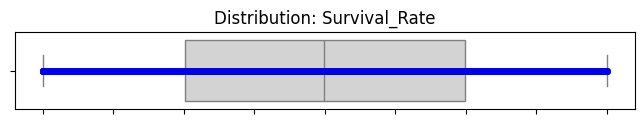

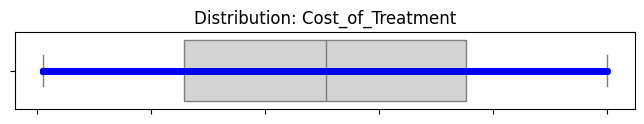

In [179]:
def plot_attribute(title, attribute):
    plt.figure(figsize=(8, 1))
    ax = sns.boxplot(x=attribute, color='lightgray', showfliers=False)
    _ = ax.set(xlabel=None)
    _ = ax.set(xticklabels=[])
    ax = sns.stripplot(x=attribute, color='blue', alpha=0.05, jitter=False)
    _ = ax.set(xlabel=None)
    plt.title(f'Distribution: {title}')

plot_attribute('Country', df['Country'])

numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plot_attribute(col, df[col])    

Check the variance of `Population` attribute per `Country`: 

In [180]:
population_check = df.groupby('Country')['Population'].agg(['min', 'max', 'mean', 'std', 'count'])
display(population_check.head(10))

,min,max,mean,std,count
Country,,,,,
Bangladesh,1012010,1499920071,7.540545e+08,4.330552e+08,5388
Brazil,1043910,1499860069,7.467732e+08,4.336020e+08,5385
China,1132575,1499851348,7.439696e+08,4.306265e+08,5261
Colombia,1216937,1499976173,7.554990e+08,4.326091e+08,5259
DR Congo,1047917,1499862185,7.546457e+08,4.335057e+08,5448
Egypt,1089335,1499743473,7.583246e+08,4.303062e+08,5449
Ethiopia,1651940,1499858609,7.563275e+08,4.272984e+08,5307
France,1046464,1499877382,7.477193e+08,4.270706e+08,5442
Germany,1051012,1499901601,7.462534e+08,4.341240e+08,5304


⚠️ **WARNING**
In real-world data, a country should has a single, static population metric. However this massive variance (7 * 10^8) that appear in the table above, strongly implies that these columns may be generated randomly.

**Impact on Classification**: Retaining these artificially randomized columns will severely degrade the performance of our classification models. If we feed this data into algorithms like Decision Trees, the tree will make arbitrary, highly specific splits based on these random decimal fluctuations, leading to severe overfitting. So we will not include these noisy non-informative features in the training process.

### Target Class (Prediction) Distribution

Prediction
No     75.031817
Yes    24.968183
Name: proportion, dtype: float64


<Axes: xlabel='Prediction', ylabel='count'>

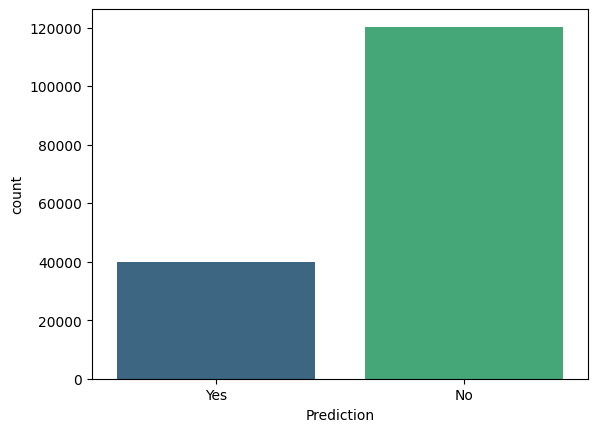

In [181]:
print(df['Prediction'].value_counts(normalize=True) * 100)
sns.countplot(data=df, x='Prediction', palette='viridis', hue='Prediction')


The target class (<code>Prediction</code>) reveals a moderately imbalanced distribution, with roughly <b>75% Negative (No)</b> and <b>25% Positive (Yes)</b> cases. <br><br>
To account for this 75/25 imbalance, we cannot rely on standard Accuracy to evaluate our classifiers. Instead, we will rely on the <b>Confusion Matrix</b>, <b>Precision</b>, <b>Recall</b>, and the <b>F1-Score</b>.

### Check for Linear Correlation between attributes

To generate a meaningful Correlation Matrix, we must first preprocess our dataset by converting all relevant categorical attributes into numerical formats. Standard One-Hot Encoding for nominal features like `Country` and `Region` would introduce high dimensionality and sparsity, making the resulting matrix cluttered and difficult to interpret. Therefore, for the purpose of this specific exploratory analysis, we will exclude these geographical identifiers and focus our Correlation Matrix entirely on the continuous, ordinal, and binary medical risk factors.

Define Data Preprocessor Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.decomposition import PCA

geo_cols = [
    'Country',
    'Region'
]

nominal_cols = [
    'Ethnicity'
]

binary_cols = [
    'Diabetes', 
    'Hepatitis_B_Status', 
    'Hepatitis_C_Status', 
    'Herbal_Medicine_Use', 
    'Gender', 
    'Smoking_Status', 
    'Rural_or_Urban', 
    'Screening_Availability', 
    'Treatment_Availability',
    'Liver_Transplant_Access'
]
 
numeric_cols = [
    'Population',
    'Cost_of_Treatment',
    'Survival_Rate',
    'Mortality_Rate',
    'Incidence_Rate',
    'Age'
]

ordinal_cols = [
    'Alcohol_Consumption', 
    'Obesity', 
    'Seafood_Consumption',
    'Healthcare_Access',
    'Preventive_Care'
]

# Define the order for ordinal columns
ordinal_categories = [
    ['Low', 'Moderate', 'High'],                      # Alcohol_Consumption
    ['Underweight', 'Normal', 'Overweight', 'Obese'], # Obesity
    ['Low', 'Medium', 'High'],                        # Seafood_Consumption
    ['Poor', 'Moderate', 'Good'],                     # Healthcare_Access
    ['Poor', 'Moderate', 'Good']                      # Preventive_Care
]

ordinal_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=ordinal_categories)),
    ('scaler', MinMaxScaler())
])

#numeric_transformer = Pipeline(steps=[
#    #('passthrough',Passthrough)
#    #('power', PowerTransformer(copy=True, method='yeo-johnson', standardize=False)),
#    ('numeric', StandardScaler())
#])

eda_preprocessor = ColumnTransformer(
    transformers=[
        # Nominal
        ('nominal', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),   
        # Ordinal
        ('ordinal', ordinal_transformer, ordinal_cols),
        # Binary
        ('binary', OrdinalEncoder(), binary_cols + ['Prediction']),
        # Numeric
        ('numeric', StandardScaler(), numeric_cols) 
    ], remainder='passthrough'
)

In [183]:
eda_df = df.copy().drop(columns=geo_cols)
eda_preprocessor.set_output(transform='pandas')
eda_df = eda_preprocessor.fit_transform(eda_df)

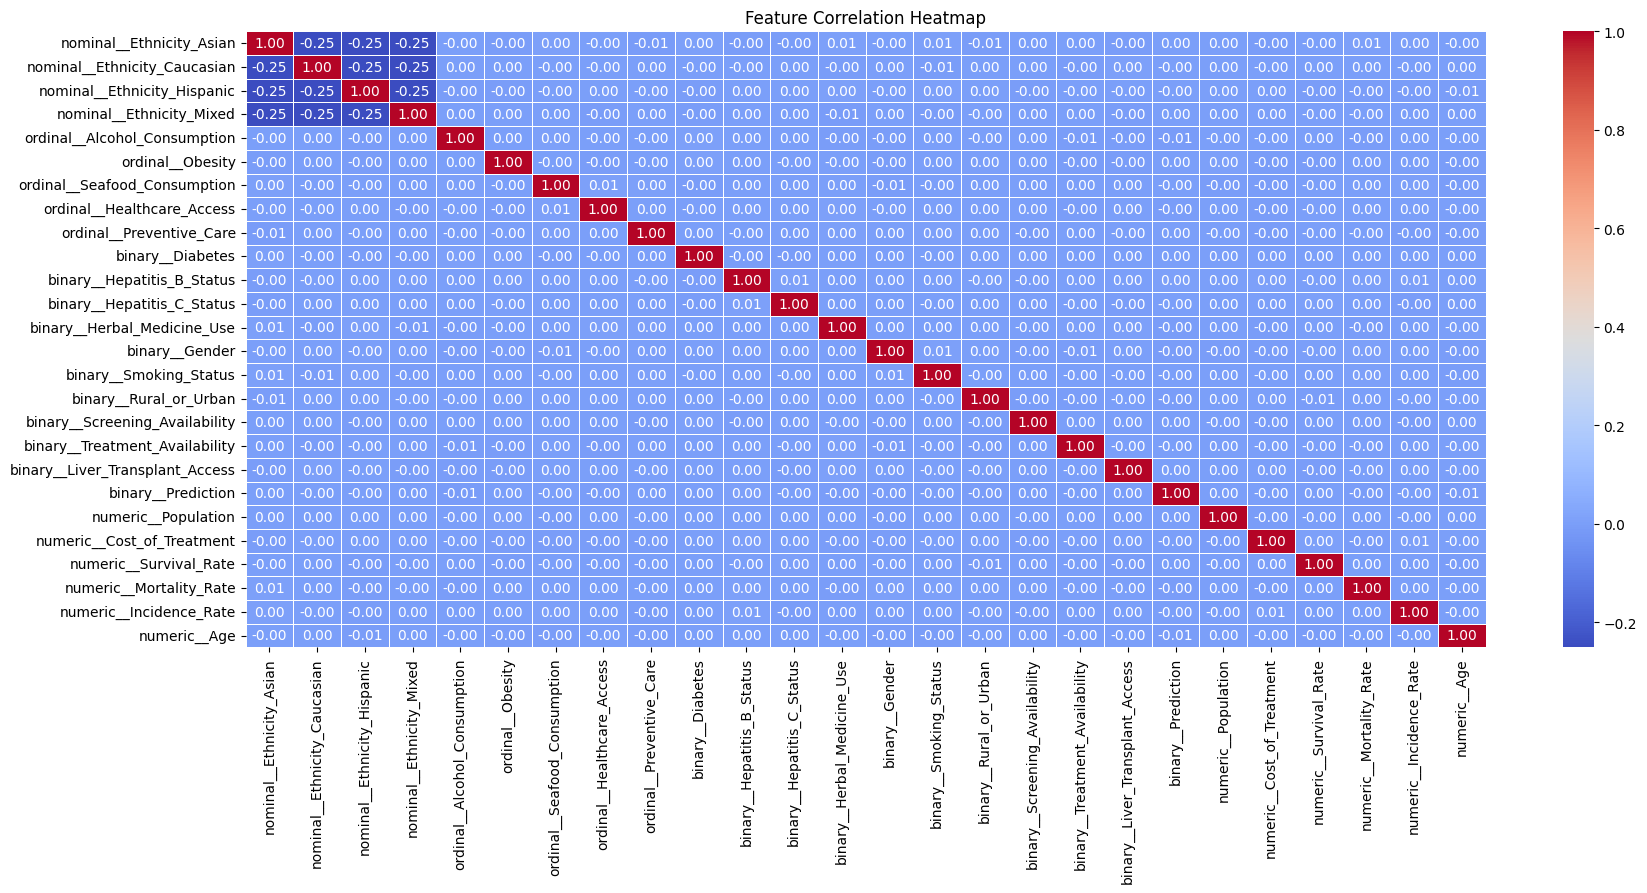

In [184]:
# Compute and plot correlation matrix
corr_matrix = eda_df.corr()
plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

<div class="alert alert-danger">
<b>🚨 Absence of Correlation Between Attributes</b><br><br>
Our correlation analysis revealed two major statistical anomalies:
<ul>
    <li>First, the feature-to-feature correlation matrix closely represent an identity matrix, indicating a complete lack of correlation between the attributes.</li>
    <li>Second, and most critically, the correlation between all independent features and the target variable (<code>Prediction</code>) is practically zero (max ~0.01).</li>
</ul>
    This maybe an indicator that the dataset is synthetic and was generated randomly.<br>
<b>Impact on Classification:</b>
Because there is no linear or mathematical relationship for the algorithms to learn, we anticipate the following behaviors during evaluation:
<ul>
    <li>The overall Accuracy of the models will likely mirror the baseline distribution.</li>
    <li>we expect the Precision, Recall, and F1-Scores for the cancer cases to be low.</li>
</ul>
</div>

### Calculate the Information gain for all attributes:

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

def calculate_ig_all_types(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    X_encoded = X.copy()
    
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col].astype(str))
        
    y_encoded = LabelEncoder().fit_transform(y)
    
    discrete_features_indices = [X.columns.get_loc(col) 
                                 for col in X.select_dtypes(include=['object', 'category']).columns]

    # Calculate Information Gain (Mutual Information)
    ig_scores = mutual_info_classif(X_encoded, y_encoded, 
                                   discrete_features=discrete_features_indices, 
                                   random_state=42)
    
    return pd.Series(ig_scores, index=X.columns).sort_values(ascending=False)
#df.dropna()

ig_results = calculate_ig_all_types(df, 'Prediction')
ig_results


Survival_Rate              7.439820e-04
Cost_of_Treatment          6.596900e-04
Mortality_Rate             2.674001e-04
Country                    1.130184e-04
Region                     7.575887e-05
Alcohol_Consumption        2.492093e-05
Obesity                    2.353484e-05
Age                        2.075296e-05
Healthcare_Access          1.297807e-05
Hepatitis_B_Status         1.186399e-05
Ethnicity                  6.012026e-06
Rural_or_Urban             4.346650e-06
Gender                     3.922291e-06
Liver_Transplant_Access    3.632755e-06
Herbal_Medicine_Use        3.133452e-06
Screening_Availability     1.902877e-06
Diabetes                   1.212402e-06
Preventive_Care            6.566842e-07
Smoking_Status             5.171379e-07
Hepatitis_C_Status         2.582798e-07
Seafood_Consumption        8.710079e-08
Treatment_Availability     4.145515e-08
Population                 0.000000e+00
Incidence_Rate             0.000000e+00
dtype: float64

<div class="alert alert-danger">
    <b>🚨 Zero Information Gain</b><br><br>
    The highest recorded IG is nearly zero (<code>~0.0007</code> for Survival_Rate), with all other features falling below this threshold (and some, like Population, at absolute zero). These near-zero values mathematically prove that no single feature provides any meaningful discriminative power to separate the "Yes" class from the "No" class.
</div>

## Features Engineering


As a try to enhance the predictive capabilities of our models, we engineered a new continuous feature: the <code>Risk_Factor_Score</code>. This feature was constructed by combining some existing attributes(features) mathematically.

<code>Risk_Factor_Score = 3 * Hepatitis_B + 3 * Hepatitis_C + (2/1) * Alcohol_Consumption + (3/2) * Obesity + Diabetes + 2 * Smoking_Status</code>

In [ ]:
def feature_engineering(df):
    hep_b_risk = df['Hepatitis_B_Status'].map({'Positive': 3, 'Negative': 0}).fillna(0)
    hep_c_risk = df['Hepatitis_C_Status'].map({'Positive': 3, 'Negative': 0}).fillna(0)

    alcohol_risk = df['Alcohol_Consumption'].map({'High': 2, 'Moderate': 1, 'Low': 0}).fillna(0)

    obesity_risk = df['Obesity'].map({'Obese':3, 'Overweight':2, 'Normal': 0, 'Underweight': 3}).fillna(0)
    diabetes_risk = df['Diabetes'].map({'Yes': 1, 'No': 0}).fillna(0)

    smoking_risk = df['Smoking_Status'].map({'Smoker': 2, 'Non-Smoker': 0}).fillna(0)

    df['Risk_Factor_Score'] = (hep_b_risk + hep_c_risk + alcohol_risk + obesity_risk + diabetes_risk + smoking_risk)
    
feature_engineering(df)

df['Risk_Factor_Score'].sample(5)

110784    3
91208     2
70832     5
153799    6
108025    9
Name: Risk_Factor_Score, dtype: int64

In [ ]:
df[['Risk_Factor_Score','Hepatitis_C_Status','Alcohol_Consumption','Obesity','Diabetes','Smoking_Status', 'Prediction']].sample(10)

,Risk_Factor_Score,Hepatitis_C_Status,Alcohol_Consumption,Obesity,Diabetes,Smoking_Status,Prediction
93299,4,Negative,High,Normal,No,Smoker,No
96780,7,Negative,High,Underweight,No,Smoker,Yes
5095,5,Negative,Low,Overweight,No,Non-Smoker,No
24848,5,Negative,Moderate,Overweight,No,Smoker,No
77246,5,Negative,High,Overweight,Yes,Non-Smoker,No
72555,13,Positive,High,Underweight,No,Smoker,Yes
20001,6,Negative,High,Overweight,No,Smoker,No
63375,10,Negative,High,Obese,No,Smoker,No
101063,4,Negative,High,Overweight,No,Non-Smoker,No
146668,2,Negative,Low,Normal,No,Smoker,Yes


Calculate Information Gain of the new feature:

In [188]:
ig_results = calculate_ig_all_types(df[['Risk_Factor_Score','Hepatitis_C_Status','Alcohol_Consumption','Obesity','Diabetes','Smoking_Status', 'Prediction']], 'Prediction')
ig_results

Risk_Factor_Score      1.308298e-03
Alcohol_Consumption    2.492093e-05
Obesity                2.353484e-05
Diabetes               1.212402e-06
Smoking_Status         5.171379e-07
Hepatitis_C_Status     2.582798e-07
dtype: float64

From the results above, the Information Gain is a little bit better than the other existing features. 

## 2. Learning Models

Selecting Features and Splitting the dataset into test(20%) and train(80%) sets.

In [189]:
from sklearn.model_selection import train_test_split

def select_and_split_data(df):
    X = df[[
        #geo
        'Country',
        'Region',

        # nominal_cols
        'Ethnicity',
        
        # ordinal_cols
        'Alcohol_Consumption',
        'Obesity',
        'Seafood_Consumption',
        'Healthcare_Access',
        'Preventive_Care',
        
        # binary
        'Gender',
        'Smoking_Status',
        'Hepatitis_B_Status',
        'Hepatitis_C_Status',
        'Diabetes',
        'Rural_or_Urban',
        'Herbal_Medicine_Use',
        'Screening_Availability',
        'Treatment_Availability',
        'Liver_Transplant_Access',
        
        # numeric_cols
        'Age',
        'Risk_Factor_Score',
        # drop the following features because we think they are just a random noise. 
        # As illustrated before in EDA section 
        # 'Population',
        # 'Cost_of_Treatment',
        # 'Survival_Rate',
        # 'Mortality_Rate',
        # 'Incidence_Rate',
    ]]
    
    y = df['Prediction'].map({'No': 0, 'Yes': 1})
    

    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = select_and_split_data(df)

Defining the preprocessing pipeline: Similar to the preprocessor we used above in the EDA version, but now including one-hot-encoded Country and Region columns. We use PCA (3 components) to handle the high cardinality of these features.

In [ ]:
# Create a mini-pipeline specifically for the geographic (Country And Region) data
geo_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
    ('pca', PCA(n_components=3))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('geo_pca', geo_transformer, geo_cols),
        # Nominal
        ('nominal', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),   
        # Ordinal
        ('ordinal', ordinal_transformer, ordinal_cols),
        # Binary
        ('binary', OrdinalEncoder(), binary_cols),
        # Numeric
        ('numeric', StandardScaler(), ['Age','Risk_Factor_Score']) 
    ],remainder='passthrough'
)

Testing data preprocessor pipeline.

In [191]:
preprocessor.set_output(transform='pandas')
XT = preprocessor.fit_transform(X_train)
XT.head()

,geo_pca__pca0,geo_pca__pca1,geo_pca__pca2,nominal__Ethnicity_Asian,nominal__Ethnicity_Caucasian,nominal__Ethnicity_Hispanic,nominal__Ethnicity_Mixed,ordinal__Alcohol_Consumption,ordinal__Obesity,ordinal__Seafood_Consumption,...,binary__Hepatitis_C_Status,binary__Herbal_Medicine_Use,binary__Gender,binary__Smoking_Status,binary__Rural_or_Urban,binary__Screening_Availability,binary__Treatment_Availability,binary__Liver_Transplant_Access,numeric__Age,numeric__Risk_Factor_Score
29338,0.766824,-0.445365,-0.253188,1.0,0.0,0.0,0.0,1.0,1.000000,0.5,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,-0.875052,0.886524
57123,-0.008113,0.868448,-0.443043,1.0,0.0,0.0,0.0,0.5,1.000000,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,-0.131158,0.886524
3168,-0.002115,0.093709,0.406218,0.0,1.0,0.0,0.0,0.0,0.666667,0.5,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.604595,-0.414449
46645,-0.001690,0.071885,0.246051,0.0,0.0,0.0,0.0,0.0,1.000000,0.5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-1.222202,-0.848107
63366,-0.002318,0.106331,0.653684,0.0,0.0,0.0,0.0,0.0,0.666667,0.5,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.059073,-0.848107


Defining the classifier training pipeline, which includes a data preprocessor for data transformation, a sampler to address class imbalance within the training folds, and the final classifier training step.

In [192]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def tune_classifier(model, param_grid, title) -> Pipeline: 
    print("Learning and tuning the classifier started ...")
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        #('smote', SMOTE(random_state=42)),
        ('sampler', RandomUnderSampler(random_state=42)), 
        ('classifier', model)
    ])

    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=param_grid,
        cv=10,
        scoring='f1', # Keep optimizing for F1-score for imbalanced data
        n_jobs=-1,
        verbose=2
    )

    print("Starting Grid Search... Go grab a coffee, this will take a while!")
    grid_search.fit(X_train, y_train)

    print("\n--- Tuning Complete ---")
    print(f"Best Hyperparameters Found:\n{grid_search.best_params_}")
    print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

    best_tuned_pipeline = grid_search.best_estimator_

    # Make predictions with the tuned tree
    y_pred = best_tuned_pipeline.predict(X_test)

    # Calculate Metrics
    conf_matrix = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n--- Best {title} Performance ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Plotting the Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: Best {title}")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.show()
    print("Learning and tuning the classifier started Completed.")
    return best_tuned_pipeline

Defining the Classification Techniques that we will use and their corresponding hyper parameters that we need to tune

In [193]:
from sklearn.calibration import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1), 
        'best_tuned_pipeline': None,
        'param_grid' : {
            'classifier__n_neighbors': [5, 7, 9, 13, 15, 19, 21, 27],
        }
    },
    'SVM': {
        'model': LinearSVC(random_state=42), 
        'best_tuned_pipeline': None,
        'param_grid': {}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'best_tuned_pipeline': None,
        'param_grid' : {
            'classifier__max_depth': [10,  30, None],
            'classifier__min_samples_split': [2, 5,  15],
            'classifier__min_samples_leaf': [1, 5,  15],
            'classifier__criterion': ['gini', 'entropy']
        }
    },
    'NaiveBayes': {
        'model': GaussianNB(),
        'best_tuned_pipeline': None,
        'param_grid': {}
    }
}

## Decision Tree Classifier

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 54 candidates, totalling 540 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 15, 'classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.3348

--- Best Decision Tree Performance ---
Precision: 0.2455
Recall:    0.4883
F1-Score:  0.3267


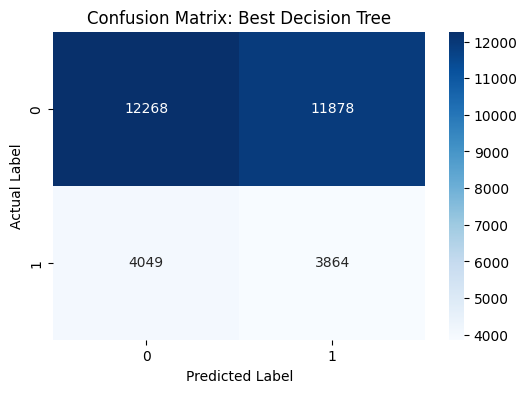

Learning and tuning the classifier started Completed.


In [194]:
model_dict = models['DecisionTree']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'Decision Tree')

## KNN

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 8 candidates, totalling 80 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'classifier__n_neighbors': 5}
Best Cross-Validation Score: 0.3365

--- Best KNN Performance ---
Precision: 0.2491
Recall:    0.5042
F1-Score:  0.3334


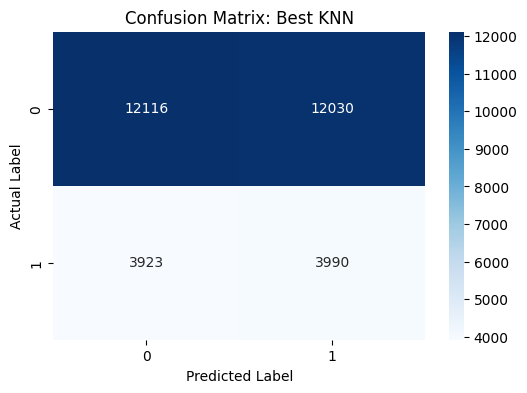

Learning and tuning the classifier started Completed.


In [195]:
model_dict = models['KNN']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'KNN')

## Naive Bayes

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 1 candidates, totalling 10 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{}
Best Cross-Validation Score: 0.3265

--- Best Naive Bayes Performance ---
Precision: 0.2526
Recall:    0.4720
F1-Score:  0.3291


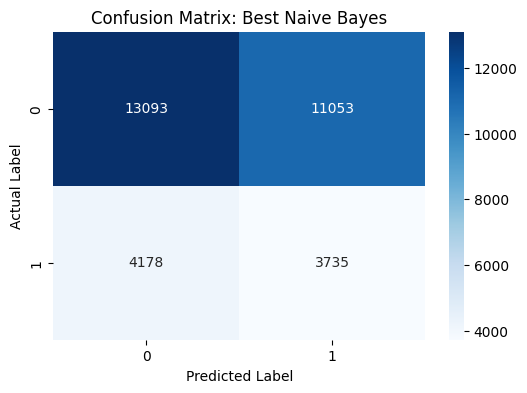

Learning and tuning the classifier started Completed.


In [196]:
model_dict = models['NaiveBayes']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'Naive Bayes')

## SVM

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 1 candidates, totalling 10 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{}
Best Cross-Validation Score: 0.3347

--- Best SVM Performance ---
Precision: 0.2498
Recall:    0.4994
F1-Score:  0.3330


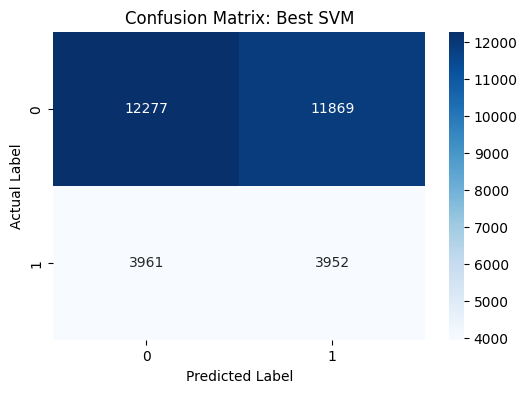

Learning and tuning the classifier started Completed.


In [197]:
model_dict = models['SVM']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'SVM')

## Draw the ROC Curves for ALL Classifiers

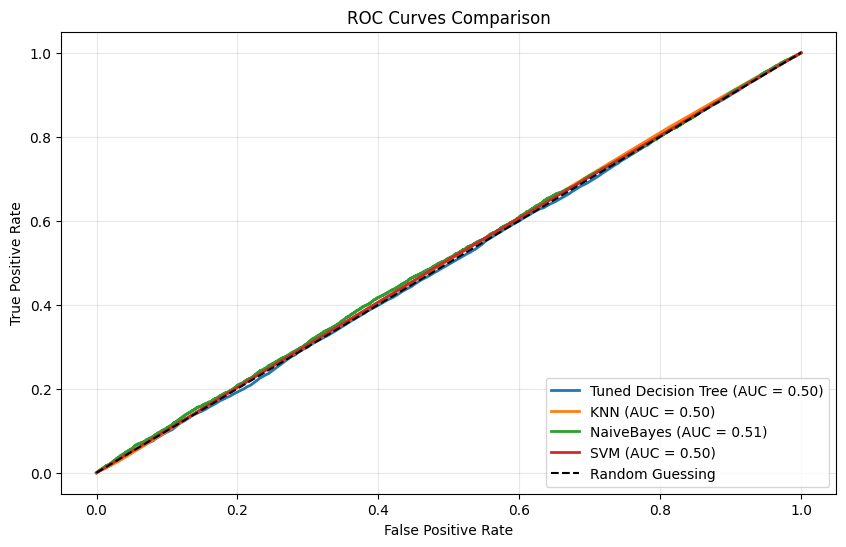

In [ ]:
def draw_roc_curves():

    # Get prediction probabilities
    y_prob_dt = models['DecisionTree']['best_tuned_pipeline'].predict_proba(X_test)[:, 1]
    y_prob_knn = models['KNN']['best_tuned_pipeline'].predict_proba(X_test)[:, 1]
    y_prob_nb = models['NaiveBayes']['best_tuned_pipeline'].predict_proba(X_test)[:, 1]
    y_prob_svm = models['SVM']['best_tuned_pipeline'].predict(X_test)

    # Calculate False Positive Rates (fpr) and True Positive Rates (tpr)
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
    fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
    fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)


    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(fpr_dt, tpr_dt, label=f'Tuned Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.2f})', linewidth=2)
    plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.2f})', linewidth=2)
    plt.plot(fpr_nb, tpr_nb, label=f'NaiveBayes (AUC = {auc(fpr_nb, tpr_nb):.2f})', linewidth=2)
    plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.2f})', linewidth=2)

    # The random guessing line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

    plt.title('ROC Curves Comparison')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()
    
draw_roc_curves()

## Draw Training vs. Validation Error Curves

Calculating learning curve for KNN...
Calculating learning curve for SVM...
Calculating learning curve for DecisionTree...
Calculating learning curve for NaiveBayes...


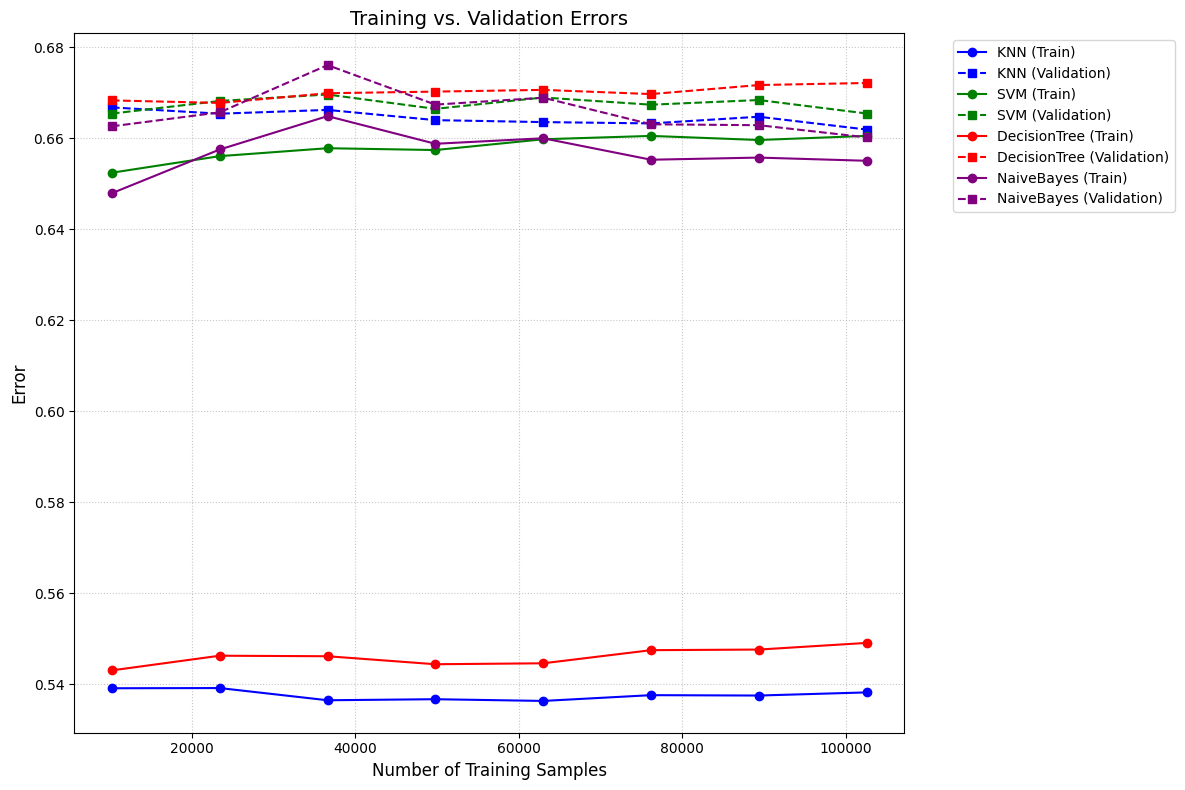

In [199]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

def draw_training_vs_validation_error_curve():
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    plt.figure(figsize=(12, 8))

    for i, (name, model) in enumerate(models.items()):
        
        print(f"Calculating learning curve for {name}...")
        
        train_sizes, train_scores, test_scores = learning_curve(
            estimator=model['best_tuned_pipeline'],
            X=X_train, 
            y=y_train,
            train_sizes=np.linspace(0.1, 1.0, 8), # 8 points to keep calculation time reasonable
            cv=5,
            scoring='f1',
            n_jobs=-1
        )
    
        train_error = 1.0 - np.mean(train_scores, axis=1)
        test_error = 1.0 - np.mean(test_scores, axis=1)
        
        # Plot Training Error (Solid Line)
        plt.plot(train_sizes, train_error, 
                color=colors[i], marker='o', linestyle='-', 
                label=f'{name} (Train)')
        
        # Plot Validation Error (Dashed Line)
        plt.plot(train_sizes, test_error, 
                color=colors[i], marker='s', linestyle='--', 
                label=f'{name} (Validation)')

    plt.title('Training vs. Validation Errors', fontsize=14)
    plt.xlabel('Number of Training Samples', fontsize=12)
    plt.ylabel('Error', fontsize=12)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
draw_training_vs_validation_error_curve()

<div class="alert alert-info">
    <b>Observations:</b><br><br>
    After training and evaluating our four classifiers (Decision Tree, KNN, Naive Bayes, and SVM), the resulting performance metrics were not good (The classifiers are guessing at random as it was clear from ROC curve). This outcome validates our earlier Exploratory Data Analysis findings regarding the dataset's random nature and lack of target correlation.<br>
    <ul>
        <li><b>Precision (~ 0.25):</b> Across all four models, Precision was around 0.25. Our target class distribution is roughly 25% positive. A precision of 0.25 mathematically indicates that when the models predict "Yes", they are essentially guessing at random, matching the baseline probability of the dataset without adding any learned intelligence.</li>
        <li><b>Recall (~ 0.47 to 0.5):</b> The models are identifying roughly half of the true positive cases. However, combined with the 0.25 Precision, this indicates the models are achieving this Recall not through accurate pattern recognition, but by guessing more Positive samples than negative ones.</li>
        <li><b>F1-Score (~ 0.33)</b></li>
    </ul><br>
    The complete absence of Information Gain and covariance fundamentally limited all classifiers to baseline random guessing.
    We expect to see distinct performance variations between different algorithms based on the shape of the data. However, all four algorithms collapsed to the exact same baseline metrics. This can be considered as another proof that the failure is data-centric.
</div>

## 3. Injecting Noise

In [200]:
def inject_label_noise(df, target_col):

    group1 = df[df[target_col] == 'Yes'].copy()
    group2 = df[df[target_col] == 'No'].copy()
    
    # Randomly select 5% of group1 and change 'Yes' to 'No'
    flip_idx_g1 = group1.sample(frac=0.05, random_state=42).index
    group1.loc[flip_idx_g1, target_col] = 'No'
    
    # Randomly select 10% of group2 and change 'No' to 'Yes'
    flip_idx_g2 = group2.sample(frac=0.10, random_state=42).index
    group2.loc[flip_idx_g2, target_col] = 'Yes'
    
    # Merge the two groups back into one dataset
    noisy_df = pd.concat([group1, group2]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Flipped {len(flip_idx_g1)} labels from 'Yes' to 'No'.")
    print(f"Flipped {len(flip_idx_g2)} labels from 'No' to 'Yes'.")
    
    return noisy_df

In [201]:
df = pd.read_csv(r"liver_cancer_prediction.csv", sep=',')
df = inject_label_noise(df,'Prediction')
feature_engineering(df)
df.sample(5)

Flipped 2001 labels from 'Yes' to 'No'.
Flipped 12027 labels from 'No' to 'Yes'.


,Country,Region,Population,Incidence_Rate,Mortality_Rate,Gender,Age,Alcohol_Consumption,Smoking_Status,Hepatitis_B_Status,...,Healthcare_Access,Screening_Availability,Treatment_Availability,Liver_Transplant_Access,Ethnicity,Preventive_Care,Survival_Rate,Cost_of_Treatment,Prediction,Risk_Factor_Score
101640,Kenya,Sub-Saharan Africa,1298419623,9.061175,26.733338,Male,88,High,Non-Smoker,Negative,...,Poor,Not Available,Available,No,African,Good,37.379725,7415.426052,No,5
160110,United States,North America,182061670,12.983658,9.332446,Male,68,Low,Non-Smoker,Negative,...,Good,Not Available,Available,No,Caucasian,Poor,71.777727,48340.734245,No,0
156926,Bangladesh,South Asia,126445051,4.158756,8.058224,Male,87,Moderate,Smoker,Positive,...,Good,Not Available,Available,No,Hispanic,Poor,29.982072,14630.428172,No,8
20934,Egypt,North Africa,379963756,8.615326,6.031226,Male,75,Low,Non-Smoker,Negative,...,Good,Available,Available,No,Hispanic,Moderate,13.327349,26159.538915,No,3
47140,DR Congo,Sub-Saharan Africa,423317882,30.518851,25.900136,Male,48,Low,Non-Smoker,Negative,...,Good,Available,Not Available,No,Caucasian,Good,31.505108,3625.364277,No,2


In [203]:
X_train, X_test, y_train, y_test = select_and_split_data(df)

## Decision Tree

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 54 candidates, totalling 540 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.3863

--- Best Decision Tree Performance ---
Precision: 0.3103
Recall:    0.4986
F1-Score:  0.3825


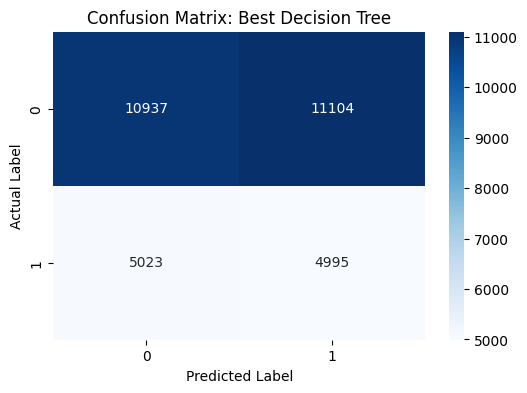

Learning and tuning the classifier started Completed.


In [204]:
model_dict = models['DecisionTree']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'Decision Tree')

## KNN

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 8 candidates, totalling 80 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{'classifier__n_neighbors': 9}
Best Cross-Validation Score: 0.3856

--- Best KNN Performance ---
Precision: 0.3093
Recall:    0.4928
F1-Score:  0.3801


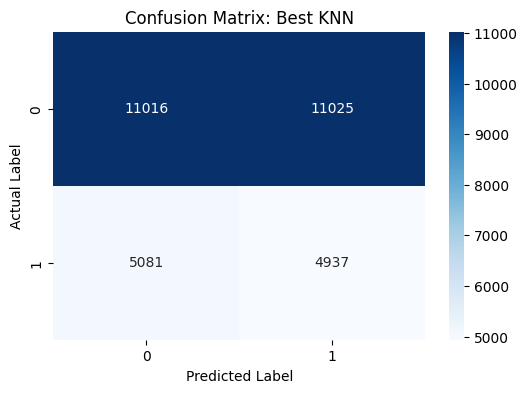

Learning and tuning the classifier started Completed.


In [205]:
model_dict = models['KNN']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'KNN')

## Naive Bayes

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 1 candidates, totalling 10 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{}
Best Cross-Validation Score: 0.3815

--- Best Naive Bayes Performance ---
Precision: 0.3115
Recall:    0.4763
F1-Score:  0.3767


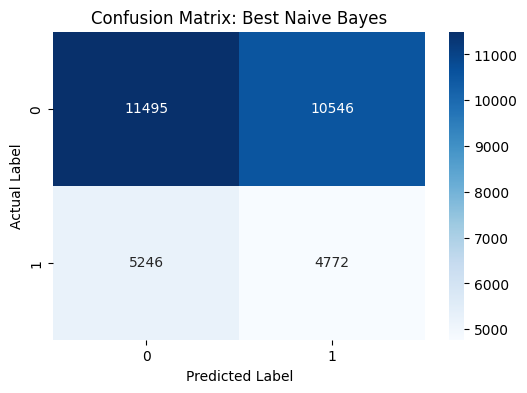

Learning and tuning the classifier started Completed.


In [206]:
model_dict = models['NaiveBayes']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'Naive Bayes')

## SVM

Learning and tuning the classifier started ...
Starting Grid Search... Go grab a coffee, this will take a while!
Fitting 10 folds for each of 1 candidates, totalling 10 fits

--- Tuning Complete ---
Best Hyperparameters Found:
{}
Best Cross-Validation Score: 0.3839

--- Best SVM Performance ---
Precision: 0.3126
Recall:    0.5006
F1-Score:  0.3849


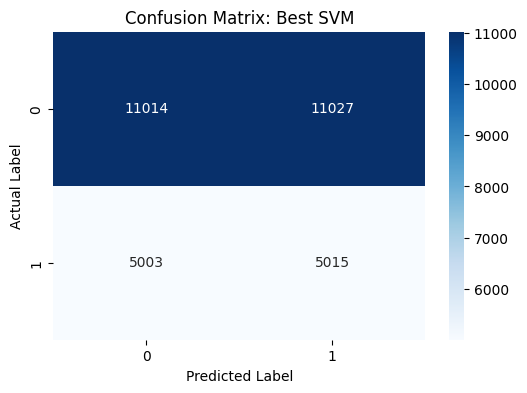

Learning and tuning the classifier started Completed.


In [207]:
model_dict = models['SVM']
model_dict['best_tuned_pipeline'] = tune_classifier(model_dict['model'], model_dict['param_grid'], 'SVM')

## Draw the ROC Curves for ALL Classifiers

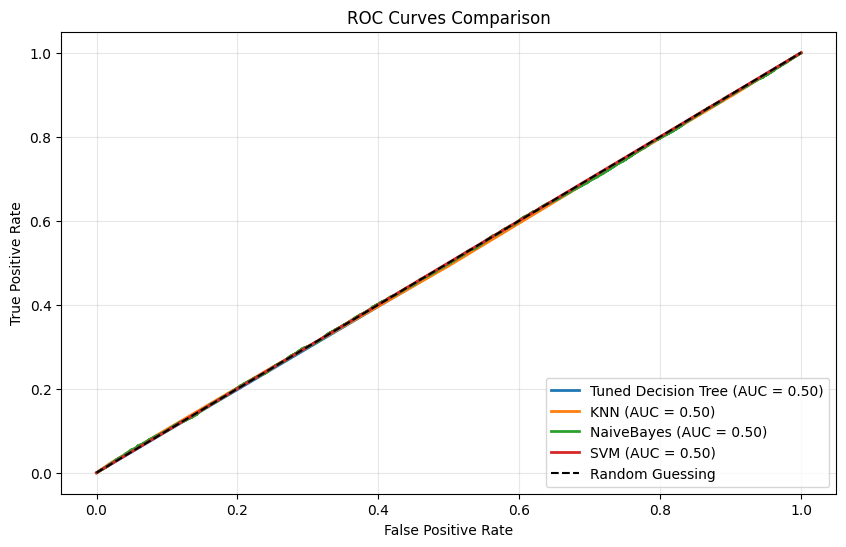

In [208]:

draw_roc_curves()

## Draw Training vs. Validation Error Curves

Calculating learning curve for KNN...
Calculating learning curve for SVM...
Calculating learning curve for DecisionTree...
Calculating learning curve for NaiveBayes...


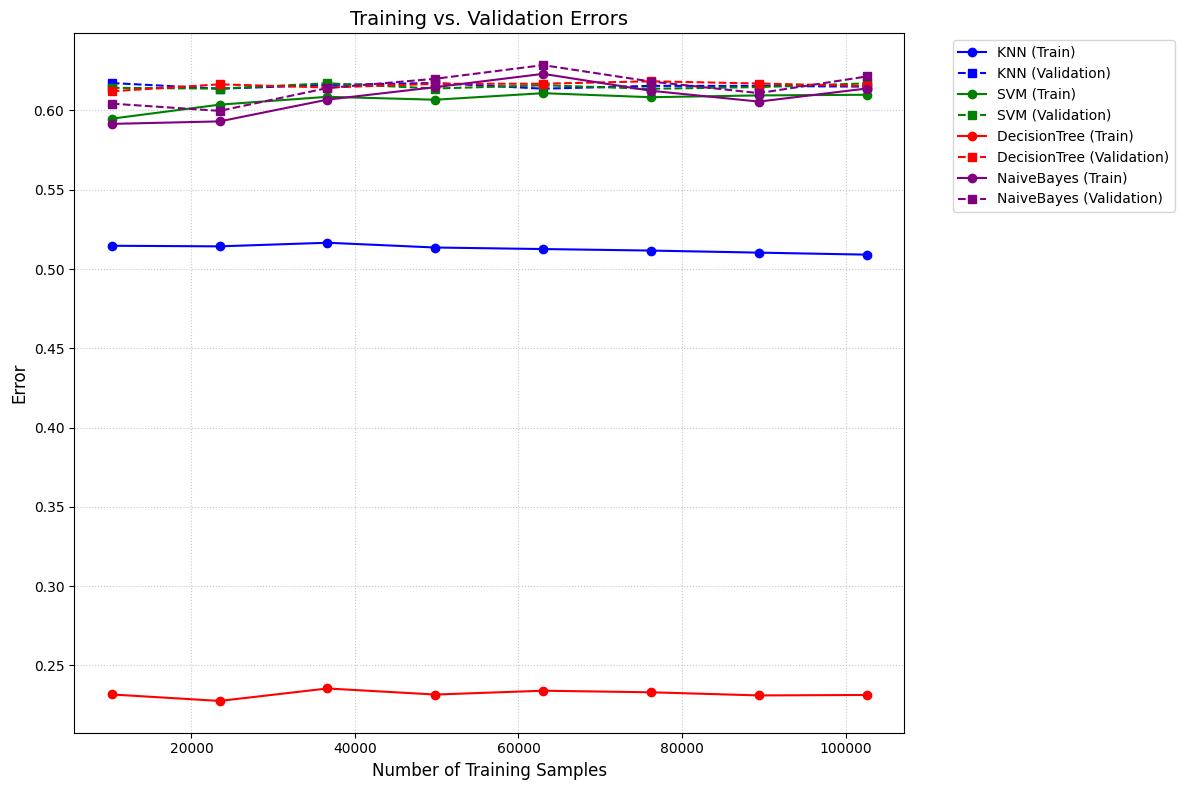

In [209]:
draw_training_vs_validation_error_curve()

<div class="alert alert-info">
    <b>Observations:</b><br>
    Injecting systematic label noise resulted in a noticeable increase in Precision (from ~0.25 to ~0.31) across all four classifiers. However, this is not an improvement in the models predictive power; it is a direct result of the change in the baseline distribution of the `Prediction` Attribute.<br>
    Before noise injection, the dataset had a 75% (No) and 25% (Yes) split. By injecting noise, we altered the total prevalence of the positive class. We have added a net of <b>+7.5%</b> to the total "Yes" group and removed a net <b>-1.25%</b> from that group. As a result, the new proportion of the "Yes" class is approximately <b>25% + 7.5% - 1.25% = 31.25%</b>.
</div>